In [ ]:

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive/yolo

adversarial_data_set_dis_dag.zip
adversarial_data_set_fgsm.zip
adversarial_data_set_fool_detectors.zip
adversarial_data_set_pgd_02.zip
adversarial_data_set_pgd_1.zip
adversarial_data_set_square2.zip
adversarial_data_set_square3.zip
adversarial_data_set_square4.zip
adversarial_data_set_square.zip
adversarial_dataset_targeted_dag.zip
adversarial_data_set_UAP.zip
adversarial_test_images_hop.zip
fgsm_augmented_images.zip
in_images.zip
PGD_augmented_images.zip
Tdag_augmented_images.zip
uap_augmented_images.zip
yolov8n_TrafficSigns_Adversarial_training.pt
yolov8n_TrafficSigns.pt


In [29]:
!cp -r /content/drive/MyDrive/yolo/PGD_augmented_images.zip /content/
!unzip -q PGD_augmented_images.zip

In [30]:
!cp -r /content/drive/MyDrive/yolo/fgsm_augmented_images.zip /content/
!unzip -q fgsm_augmented_images.zip

In [31]:
!cp -r /content/drive/MyDrive/yolo/uap_augmented_images.zip /content/
!unzip -q uap_augmented_images.zip

In [32]:
!cp -r /content/drive/MyDrive/yolo/Tdag_augmented_images.zip /content/
!unzip -q Tdag_augmented_images.zip

In [33]:
import os
import shutil

source_dirs = ['/content/content/PGD_augmented_images/images', '/content/content/fgsm_augmented_images/images', '/content/content/uap_augmented_images/images', '/content/content/Tdag_augmented_images/images']
destination_dir = '/content/adversarial_images'

# Create the destination directory if it doesn't exist
os.makedirs(destination_dir, exist_ok=True)

for source_dir in source_dirs:
  for filename in os.listdir(source_dir):
    source_path = os.path.join(source_dir, filename)
    destination_path = os.path.join(destination_dir, filename)

    # Check if the file exists in the destination directory
    if os.path.exists(destination_path):
      # If the file exists, append a number to the filename to avoid overwriting
      base_name, extension = os.path.splitext(filename)
      i = 1
      while os.path.exists(destination_path):
        new_filename = f"{base_name}_{i}{extension}"
        destination_path = os.path.join(destination_dir, new_filename)
        i += 1

    # Copy the file to the destination directory
    shutil.copy2(source_path, destination_path) # shutil.copy2 preserves metadata
print(f"Files merged into {destination_dir}")


Files merged into /content/adversarial_images


In [34]:
!rm -rf /content/content/

Found 5482 adversarial images (.png).
Retrieved 5482 original images (.jpg).
Displaying 5 image pairs.


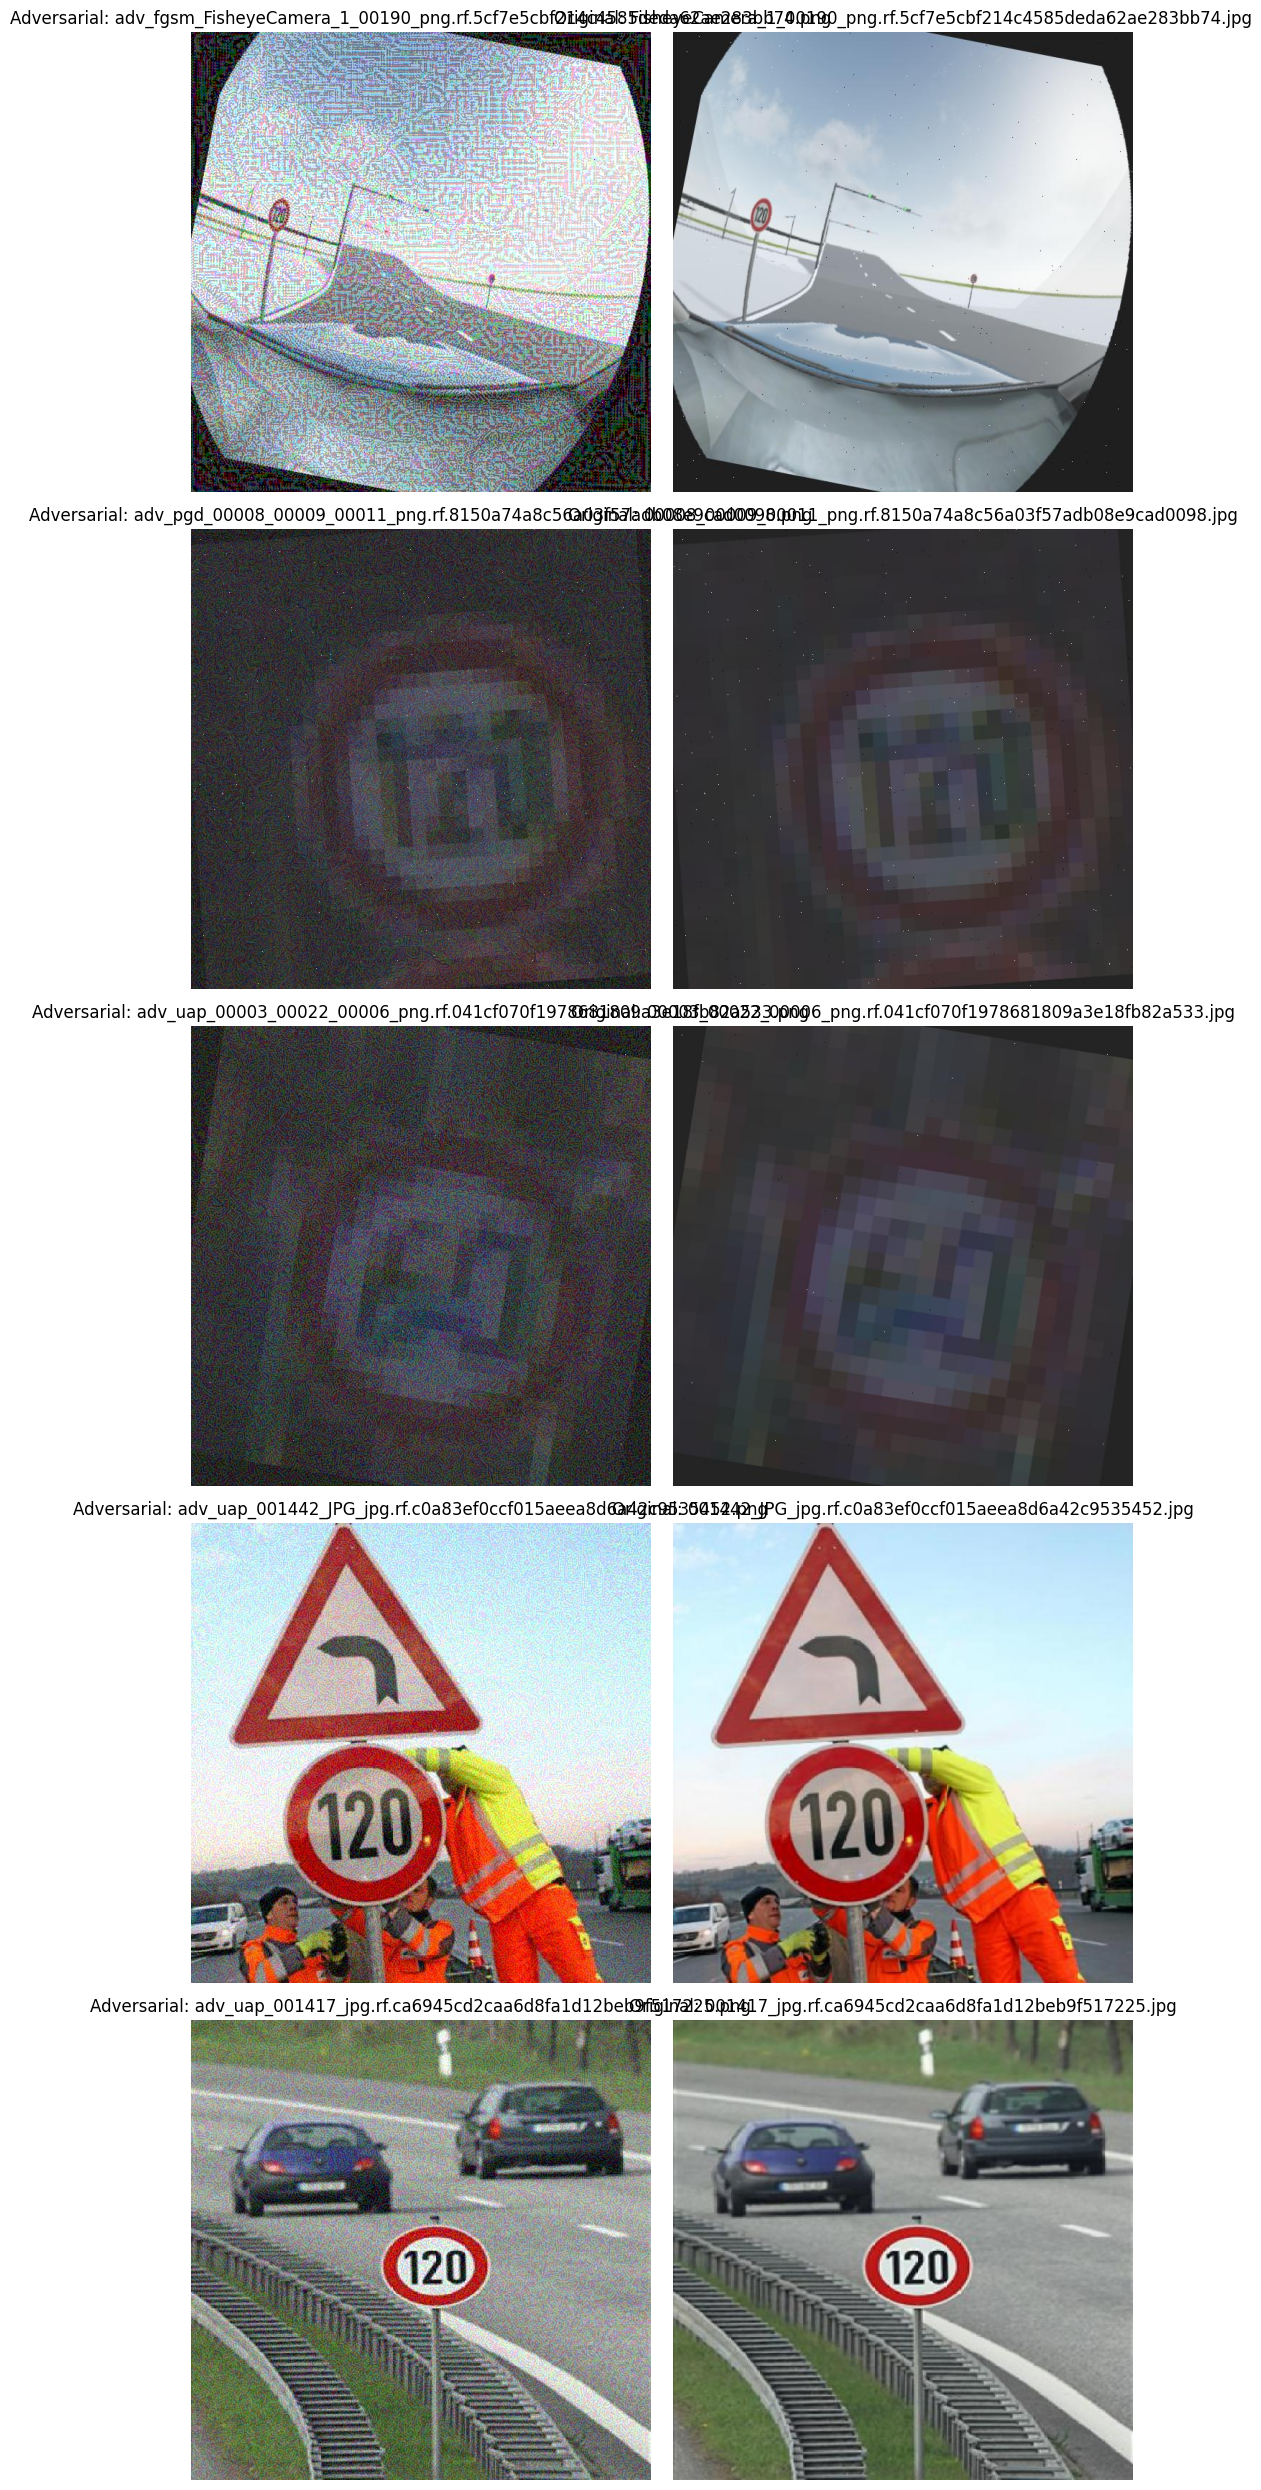

In [36]:
import os
from pathlib import Path
import shutil

import matplotlib.pyplot as plt
from PIL import Image

def display_image_pairs(adversarial_paths, original_paths, num_pairs=5):
    """
    Display pairs of adversarial and original images side by side.

    Args:
        adversarial_paths (list): List of adversarial image paths (.png).
        original_paths (list): List of corresponding original image paths (.jpg).
        num_pairs (int): Number of pairs to display.
    """
    # Limit the number of pairs to display
    num_pairs = min(num_pairs, len(adversarial_paths))
    if num_pairs == 0:
        print("No image pairs to display.")
        return

    # Set up the plot
    fig, axes = plt.subplots(num_pairs, 2, figsize=(10, 5 * num_pairs))
    if num_pairs == 1:
        axes = [axes]  # Ensure axes is iterable for a single pair

    for i in range(num_pairs):
        # Load adversarial and original images
        try:
            adv_img = Image.open(adversarial_paths[i])
            orig_img = Image.open(original_paths[i])

            # Display adversarial image
            axes[i][0].imshow(adv_img)
            axes[i][0].set_title(f"Adversarial: {Path(adversarial_paths[i]).name}")
            axes[i][0].axis('off')

            # Display original image
            axes[i][1].imshow(orig_img)
            axes[i][1].set_title(f"Original: {Path(original_paths[i]).name}")
            axes[i][1].axis('off')

        except Exception as e:
            print(f"Error displaying pair {adversarial_paths[i]} and {original_paths[i]}: {e}")

    plt.tight_layout()
    plt.show()



def retrieve_original_images(adversarial_dir, original_dir, output_dir=None, display_num=5):
    """
    Retrieve original .jpg images corresponding to adversarial .png images by removing prefixes
    and converting extensions. Optionally display some pairs.

    Args:
        adversarial_dir (str): Directory containing adversarial images (e.g., adv_fgsm_image123.png).
        original_dir (str): Directory containing original images (e.g., image123.jpg).
        output_dir (str, optional): Directory to save retrieved original images. If None, only prints paths.
        display_num (int): Number of image pairs to display for verification.

    Returns:
        tuple: (list of adversarial paths, list of original paths) for the retrieved pairs.
    """
    # Convert directories to Path objects
    adversarial_dir = Path(adversarial_dir)
    original_dir = Path(original_dir)
    if output_dir:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)

    # Define adversarial prefixes
    prefixes = ['adv_fgsm_', 'adv_dag_', 'adv_uap_', 'adv_pgd_']

    # List adversarial images (.png)
    adversarial_files = [f for f in adversarial_dir.glob("*.png") if f.is_file()]
    print(f"Found {len(adversarial_files)} adversarial images (.png).")

    # Store paths to adversarial and original images
    adversarial_image_paths = []
    original_image_paths = []
    missing_images = []

    # Process each adversarial image
    for adv_file in adversarial_files:
        adv_name = adv_file.name
        # Remove adversarial prefix
        original_name = None
        for prefix in prefixes:
            if adv_name.startswith(prefix):
                original_name = adv_name[len(prefix):]
                break

        if original_name:
            # Replace .png with .jpg to match original image extension
            original_name = original_name.replace('.png', '.jpg')
            # Construct path to original image
            original_path = original_dir / original_name
            if original_path.exists():
                adversarial_image_paths.append(str(adv_file))
                original_image_paths.append(str(original_path))
                # Optionally copy to output directory
                if output_dir:
                    shutil.copy(original_path, output_dir / original_name)
            else:
                missing_images.append(original_name)
                print(f"Original image not found: {original_name}")
        else:
            print(f"No valid prefix found in adversarial image: {adv_name}")

    print(f"Retrieved {len(original_image_paths)} original images (.jpg).")
    if missing_images:
        print(f"Missing {len(missing_images)} original images: {missing_images[:5]} (showing first 5 if many).")

    # Display a few pairs for verification
    if display_num > 0 and original_image_paths:
        print(f"Displaying {min(display_num, len(original_image_paths))} image pairs.")
        display_image_pairs(adversarial_image_paths, original_image_paths, num_pairs=display_num)

    return adversarial_image_paths, original_image_paths


# Example usage
adversarial_dir = "/content/adversarial_images"  # Replace with your adversarial images directory
original_dir = "/content/train/images"           # Replace with your original dataset directory
output_dir = "/content/original_images"      # Optional: where to save retrieved images

display_num = 5                                  # Number of pairs to display

adv_paths, orig_paths = retrieve_original_images(adversarial_dir, original_dir, output_dir, display_num)


In [37]:
!pip install torch torchvision tqdm

import os
import glob
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tqdm import tqdm
import matplotlib.pyplot as plt

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 110.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 81.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 41.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [55]:
class ImageDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        img = Image.open(img_path).convert('RGB')

        if self.transform:
            img = self.transform(img)

        return img, label

# Define transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # MobileNetV2 expects 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet normalization
])


In [59]:
def load_dataset(clean_dir='/content/original_images', adv_dir='/content/adversarial_images'):
    clean_images = glob.glob(os.path.join(clean_dir, '*.jpg'))
    adv_images = glob.glob(os.path.join(adv_dir, '*.png'))

    # Labels: 0 for clean, 1 for adversarial
    clean_labels = [0] * len(clean_images)
    adv_labels = [1] * len(adv_images)

    # Combine
    all_images = clean_images + adv_images
    all_labels = clean_labels + adv_labels
    print(f"Clean images: {len(clean_images)}, Adversarial images: {len(adv_images)}")
    print(f"Dataset: {len(all_images)} images")

    # Shuffle and split: 70% train, 15% val, 15% test
    train_images, temp_images, train_labels, temp_labels = train_test_split(
        all_images, all_labels, test_size=0.2, random_state=42, stratify=all_labels
    )
    val_images, test_images, val_labels, test_labels = train_test_split(
        temp_images, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels
    )

    print(f"Dataset: {len(train_images)} train, {len(val_images)} val, {len(test_images)} test")
    return (train_images, train_labels), (val_images, val_labels), (test_images, test_labels)

# Load dataset
(train_images, train_labels), (val_images, val_labels), (test_images, test_labels) = load_dataset()

# Create datasets
train_dataset = ImageDataset(train_images, train_labels, transform=transform)
val_dataset = ImageDataset(val_images, val_labels, transform=transform)
test_dataset = ImageDataset(test_images, test_labels, transform=transform)

# Create data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)


Clean images: 5482, Adversarial images: 5482
Dataset: 10964 images
Dataset: 8771 train, 1096 val, 1097 test


In [60]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load MobileNetV2 with pre-trained weights
model = models.mobilenet_v2(pretrained=True)

# Modify the classifier for binary classification
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)  # 2 classes: clean, adversarial
model = model.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


Using device: cuda


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/10: 100%|██████████| 275/275 [01:45<00:00,  2.61it/s]


Epoch 1/10:
Train Loss: 0.0115, Val Loss: 0.0323, Val Accuracy: 0.9936
Saved best model with Val Loss: 0.0323


Epoch 2/10: 100%|██████████| 275/275 [01:43<00:00,  2.65it/s]


Epoch 2/10:
Train Loss: 0.0250, Val Loss: 0.0158, Val Accuracy: 0.9945
Saved best model with Val Loss: 0.0158


Epoch 3/10: 100%|██████████| 275/275 [01:44<00:00,  2.64it/s]


...

Epoch 4/10:
Train Loss: 0.0391, Val Loss: 0.0073, Val Accuracy: 0.9973
Saved best model with Val Loss: 0.0073


Epoch 5/10: 100%|██████████| 275/275 [01:44<00:00,  2.64it/s]


Epoch 5/10:
Train Loss: 0.0099, Val Loss: 0.0163, Val Accuracy: 0.9945
Patience counter: 1/2


Epoch 6/10: 100%|██████████| 275/275 [01:47<00:00,  2.56it/s]


Epoch 6/10:
Train Loss: 0.0237, Val Loss: 0.0340, Val Accuracy: 0.9936
Patience counter: 2/2
Early stopping triggered after epoch 6
Loaded best model from /content/classifier_mobilenetv2_best.pth


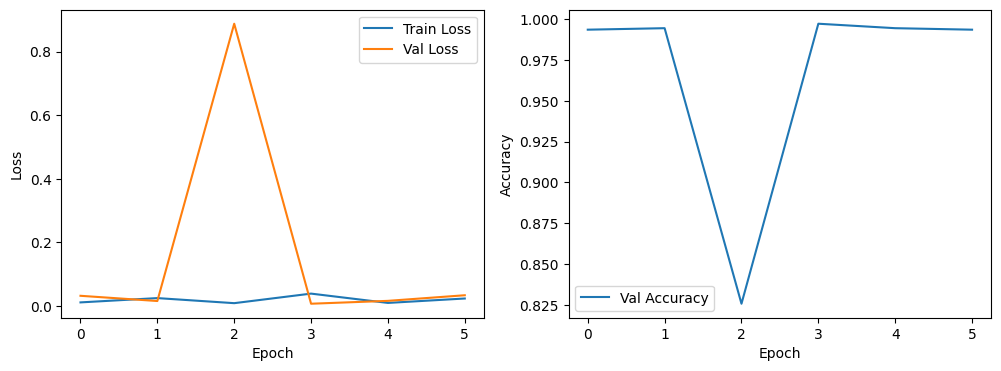

In [62]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10, patience=2):
    train_losses = []
    val_losses = []
    val_accuracies = []

    best_val_loss = float('inf')
    best_model_path = '/content/classifier_mobilenetv2_best.pth'
    patience_counter = 0

    for epoch in range(num_epochs):
        # Training
        model.train()
        running_loss = 0.0
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        # Validation
        model.eval()
        val_loss = 0.0
        preds, true_labels = [], []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)

                _, predicted = torch.max(outputs, 1)
                preds.extend(predicted.cpu().numpy())
                true_labels.extend(labels.cpu().numpy())

        epoch_val_loss = val_loss / len(val_loader.dataset)
        val_accuracy = accuracy_score(true_labels, preds)
        val_losses.append(epoch_val_loss)
        val_accuracies.append(val_accuracy)

        print(f"Epoch {epoch+1}/{num_epochs}:")
        print(f"Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")

        # Early stopping and best model saving
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f"Saved best model with Val Loss: {best_val_loss:.4f}")
            patience_counter = 0
        else:
            patience_counter += 1
            print(f"Patience counter: {patience_counter}/{patience}")
            if patience_counter >= patience:
                print(f"Early stopping triggered after epoch {epoch+1}")
                break

    # Load the best model for evaluation
    model.load_state_dict(torch.load(best_model_path))
    print(f"Loaded best model from {best_model_path}")

    return train_losses, val_losses, val_accuracies

# Train the model
num_epochs = 10
patience = 2
train_losses, val_losses, val_accuracies = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, patience)

# Plot training curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [63]:
def evaluate_model(model, test_loader):
    model.eval()
    preds, true_labels = [], []
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Evaluating"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(true_labels, preds)
    precision = precision_score(true_labels, preds)
    recall = recall_score(true_labels, preds)
    f1 = f1_score(true_labels, preds)

    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Test Precision: {precision:.4f}")
    print(f"Test Recall: {recall:.4f}")
    print(f"Test F1-Score: {f1:.4f}")

    return accuracy, precision, recall, f1

# Evaluate the model
test_metrics = evaluate_model(model, test_loader)

# Save the model
torch.save(model.state_dict(), '/content/classifier_mobilenetv2.pth')
print("Model saved to /content/classifier_mobilenetv2.pth")

Evaluating: 100%|██████████| 35/35 [00:16<00:00,  2.12it/s]

Test Accuracy: 0.9973
Test Precision: 0.9964
Test Recall: 0.9982
Test F1-Score: 0.9973
Model saved to /content/classifier_mobilenetv2.pth


In [64]:
!cp /content/classifier_mobilenetv2.pth /content/drive/MyDrive/yolo/